In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *


# Analyse

In [2]:


def chunked_file_reader(filepath, chunksize=1e7, usecols=None):
        for chunk in pd.read_csv(filepath, compression='gzip', delim_whitespace=True, header=None, chunksize=chunksize, usecols=usecols):
            yield chunk

def process_folderE(folder , limdata):

    nbline = 0
    lasttime = 0
    max_inter = 0
    last_filtered_time = 0
    avgtime = 0
    
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=1e7, usecols=[1,8]):
        time = np.array(np.cumsum(chunk.iloc[:, 0])) + lasttime
        avgtime += np.sum(chunk.iloc[:, 0])
        
        lasttime = time[-1]
        time_filtered = time[chunk.iloc[:, 1] >= 100]
        time_filtered = np.insert(time_filtered, 0, last_filtered_time)
        last_filtered_time = time_filtered[-1]
        
        if(len(time_filtered) > 0):
            time_inter = np.diff(time_filtered)
            if (np.max(time_inter) > max_inter):
                max_inter = np.max(time_inter)
        
        nbline += len(chunk.iloc[:, 0])
        if nbline >= limdata:
            break
    
    avgtime = avgtime/nbline
    
    return max_inter, avgtime, lasttime

In [3]:
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/DataML/Da1n{nb}' for nb in fnb]

Tnu = [read_parameters(folder)[2] for folder in folderpath]

NCURVES = len(folderpath) + 3 
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(1 - i / NCURVES) for i in range(NCURVES)]

max_inter = np.zeros(len(folderpath))
avgtime = np.zeros(len(folderpath))
dz_ini = np.zeros(len(folderpath))

limdata = 1e7
results = Parallel(n_jobs=-1)(delayed(process_folderE)(folder, limdata) for folder, v in zip(folderpath, Tnu))
    

for i, result in enumerate(results):
    max_inter[i], avgtime[i], dz_ini[i] = result
    
print(max_inter)
print(avgtime)
print(dz_ini)
        

KeyboardInterrupt: 

In [4]:
print(max_inter/avgtime)

[5.75865459e+02 1.35439399e+03 1.29985685e+03 1.32832645e+03
 1.47286398e+03 1.51480999e+03 1.82925556e+03 2.41813057e+03
 1.04656136e+04 3.80648778e+04 7.17553154e+04 1.15200429e+05
 1.07575722e+06 8.80500900e+06]


176.45791135360898


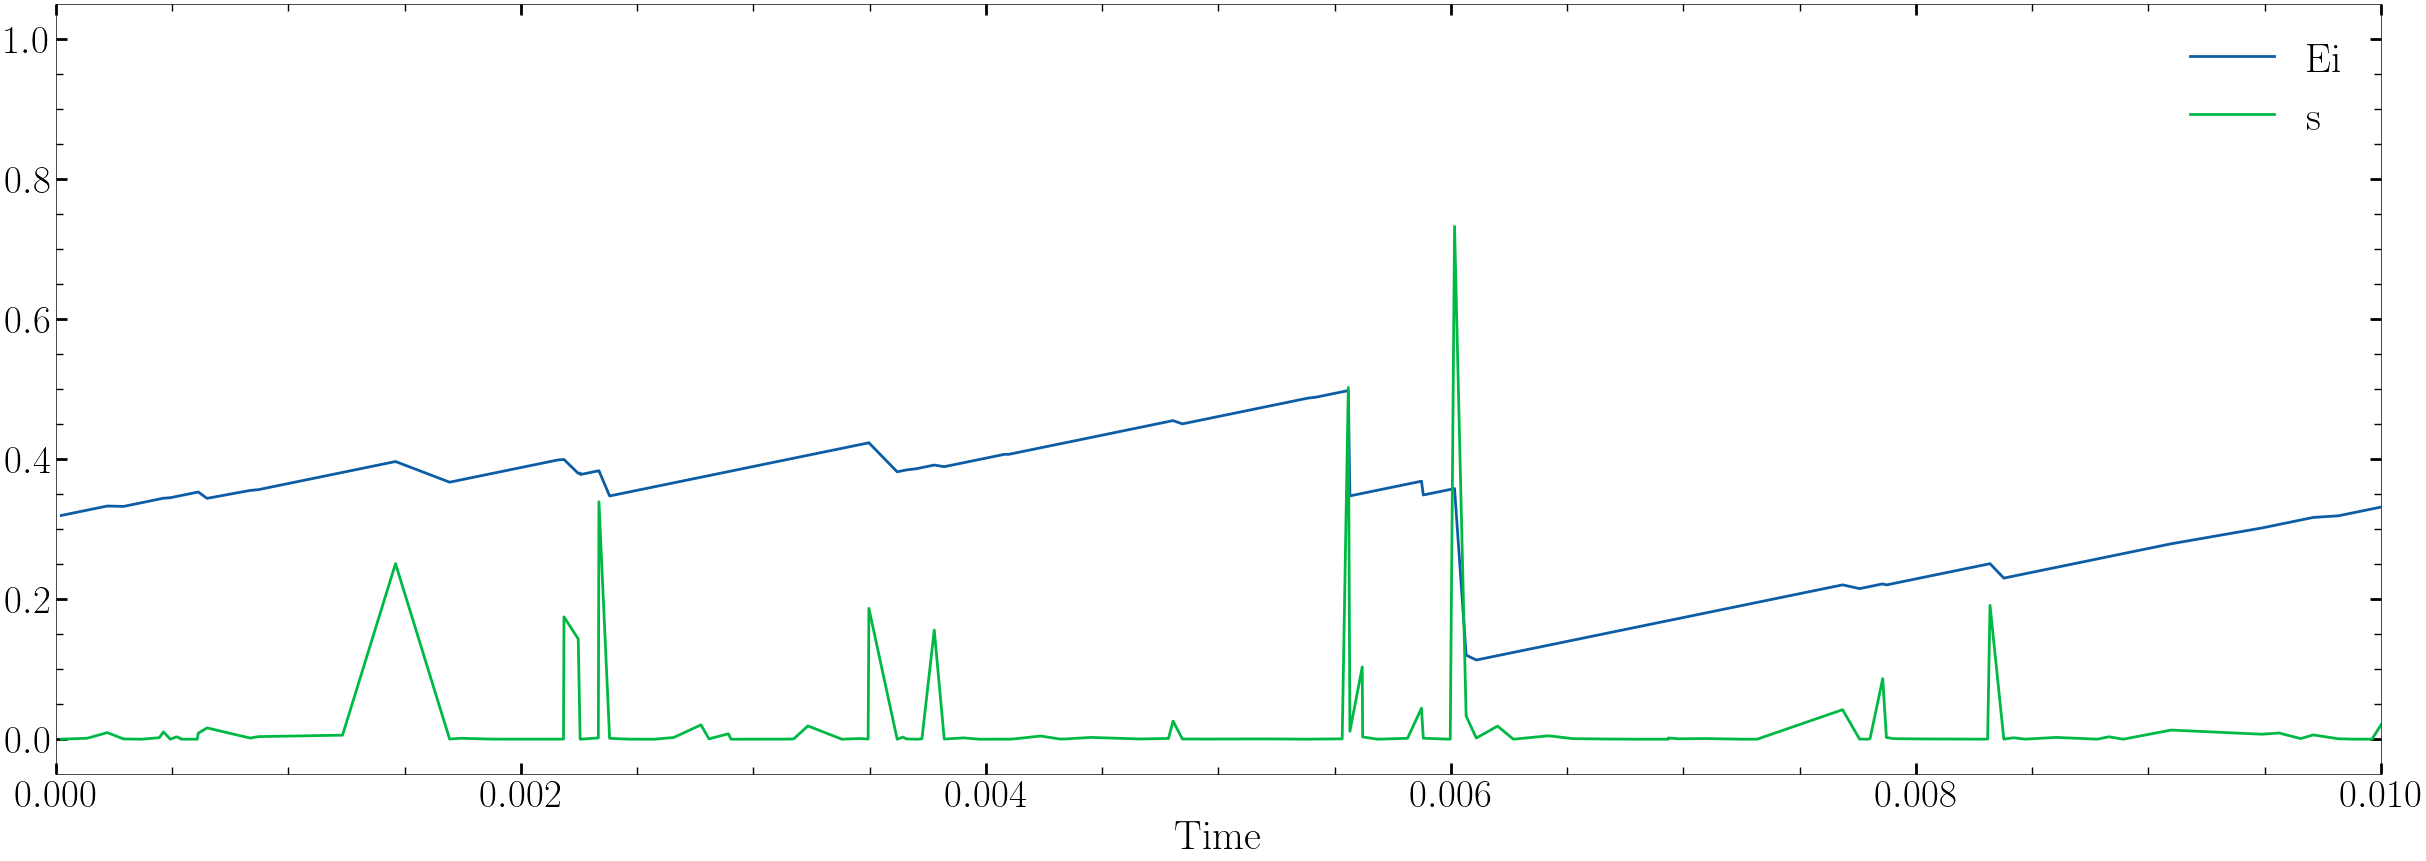

<Figure size 350x262.5 with 0 Axes>

In [16]:


data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/DataML/Da1n1/Avalanche_outputB.gz", nrows= 2000000, skiprows= 0)
# data2 = np.loadtxt('/data1/DATA_Duplat/Brut/Test/Te48n1/tflen_outputB.txt')

time = np.cumsum(data[:, 1])
print(time[-1])
plt.figure(figsize = (30,10))
plt.plot(time, (data[:,5] - np.min(data[:,5]))/ np.max(data[:,5] - np.min(data[:,5])), label = 'Ei', lw = 2)
# plt.plot(time, data[:,-1] / np.max(data[:,-1]) + 1, label = 'E_tot')
plt.plot(time, data[:, 3]/np.max(data[:, 3]), label = 's', lw = 2)
# plt.plot(time, (data[:, -2] -  np.min(data[:,-2]))/ np.max(data[:,-2] - np.min(data[:,-2])), label = 'std')
# plt.plot(time, (data[:, 1] -  np.min(data[:,1]))/ np.max(data[:,1] - np.min(data[:,1])), label = 'dt')
# plt.plot(time, data2[:len(time), 0], label = 'clen')
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.xlim(0, 0.01)
# plt.yscale("log")
plt.xlabel('Time', fontsize = 30)
plt.legend(fontsize = 30)
plt.show()
plt.savefig("time_series.pdf",)

10000


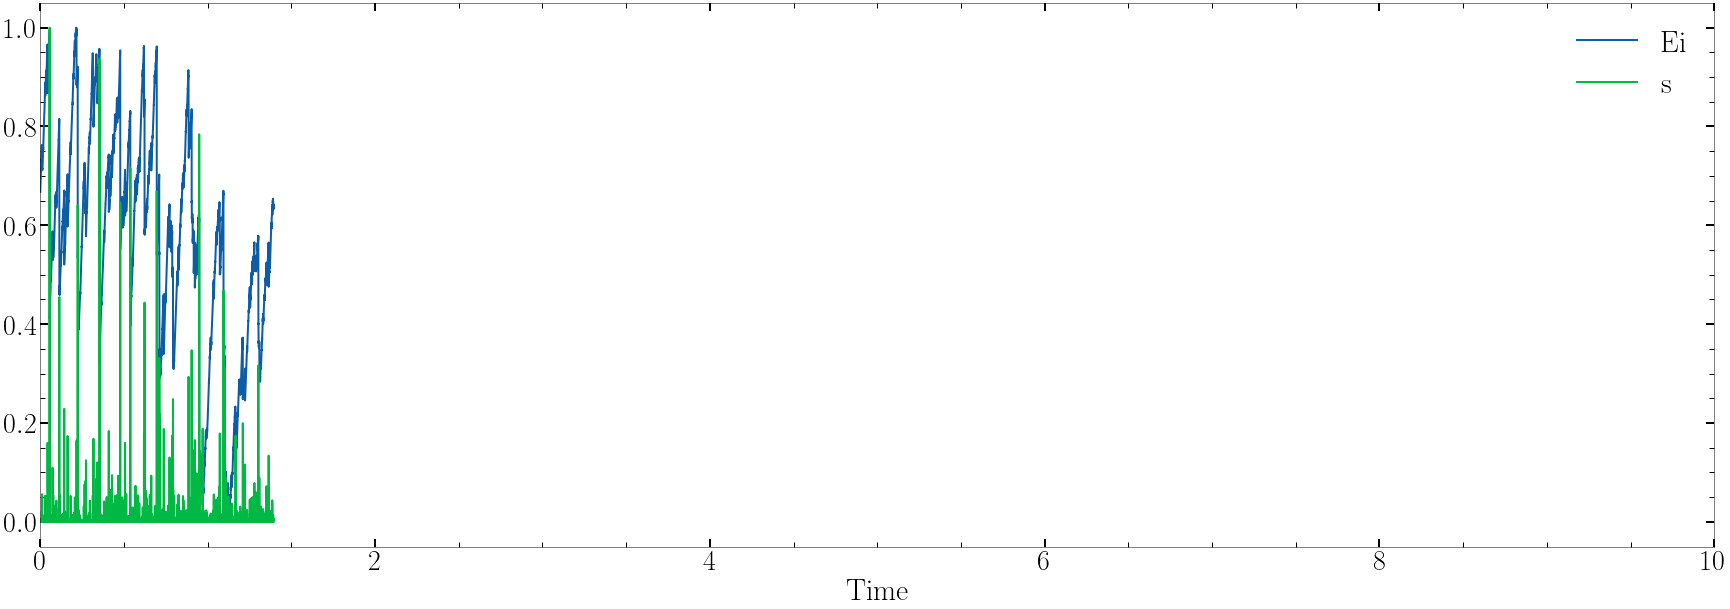

In [ ]:
data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/DataML/Da1n10/Avalanche_outputB.gz", nrows= 10000, skiprows= 0)
# data2 = np.loadtxt('/data1/DATA_Duplat/Brut/Test/Te48n1/tflen_outputB.txt')

time = np.cumsum(data[:, 1])

plt.figure(figsize = (30,10))
plt.plot(time, (data[:,5] - np.min(data[:,5]))/ np.max(data[:,5] - np.min(data[:,5])), label = 'Ei', lw = 2)
# plt.plot(time, data[:,-1] / np.max(data[:,-1]) + 1, label = 'E_tot')
plt.plot(time, data[:, 3]/np.max(data[:, 3]), label = 's', lw = 2)
# plt.plot(time, (data[:, -2] -  np.min(data[:,-2]))/ np.max(data[:,-2] - np.min(data[:,-2])), label = 'std')
# plt.plot(time, (data[:, 1] -  np.min(data[:,1]))/ np.max(data[:,1] - np.min(data[:,1])), label = 'dt')
# plt.plot(time, data2[:len(time), 0], label = 'clen')
plt.tick_params(labelsize = 28,length = 8, width = 2)
plt.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.xlim(0, 10)
# plt.yscale("log")
plt.xlabel('Time', fontsize = 30)
plt.legend(fontsize = 30)
plt.show()




In [17]:
def test_processtime_ML(folder, nbins, minsize, limdata):
    histo = np.zeros(nbins)
    bins = np.logspace(np.log10(10**-12), np.log10(10**2), nbins + 1)
    csize = 1e7
    nbdata = 0
    
    lasttime = 0
    last_filtered_time = 0
    
    ###### LOAD THE HISTOGRAM #######
    
    for chunk in chunked_file_reader(f'{folder}/Avalanche_outputB.gz', chunksize=csize, usecols = [1,3]):
        
        time = np.array(np.cumsum(chunk.iloc[:, 0])) + lasttime #rebuild the time scale starting from zero using dz
        lasttime = time[-1]  #Save the time for the next chunk
        # filterd_chunk = chunk.iloc[:, 1][chunk.iloc[:, 0] >= minsize]
        
        filtered_time = time[chunk.iloc[:, 1] >= minsize] #Keep only the avalanches with a size above a threshold
        filtered_time = np.insert(filtered_time, 0, last_filtered_time) #add to the array the time of the last avalanches from the previous chunk
        last_filtered_time = filtered_time[-1]  #Keep the time of the last avalanches for the next chunk
        
        if(len(filtered_time) > 0):
            time_inter = np.diff(filtered_time)
            histo += np.histogram(time_inter, bins = bins)[0]
            
        nbdata+=len(chunk.iloc[:, 0])
        
        if nbdata >= limdata: break
        
    ######RESCALE THE HISTOGRAM######
    
    # histo = histo/nbdata
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean = np.sum(histo * bin_centers) / np.sum(histo)

    norm_histo = histo/((np.diff(bins)) * histo.sum())
    norm_histo = norm_histo * mean

    norm_bin_centers = bin_centers/mean
        
    return norm_histo, norm_bin_centers

def test_PDFtpsbava_ML(folderpath, vartab, nbins, size = 2, nmin = [], nmax = [],
                     switch_plot = 1, limdata = 1e8, xlim_min = 1e-10, xlim_max = 2e2, ylim_min = 1e-10, ylim_max = 1e6): #PDF time between avalanches for multiple folders
    
    NCURVES = len(folderpath) 
    cmap = plt.cm.get_cmap('inferno')
    colors = [cmap(i / NCURVES) for i in range(NCURVES)]
    
    Tb, Tb2 = np.zeros(len(folderpath)), np.zeros(len(folderpath))
    
    histo = np.zeros((len(folderpath), nbins))
    bins = np.zeros((len(folderpath), nbins))
    
    results = Parallel(n_jobs=-1)(delayed(test_processtime_ML)(folder, nbins, size, limdata) for folder in folderpath)
    for i, result in enumerate(results):
        histo[i], bins[i] = result
    
    if switch_plot == 1:
        
        plt.figure(figsize = (20,10))
        ax1 = plt.subplot(1,2,1)
        for i, (v, c) in enumerate(zip(vartab, colors)):
            ax1.plot(bins[i, :][histo[i, :] != 0], histo[i][histo[i, :] != 0] , color = c, label = f'{v}', marker = 'o', linewidth = 3)
            
            try: 
                # popt, _ = curve_fit(powerlaw2, np.log(bins[i, 11:22]), np.log(histo[i, 11:22]))
                # a,b = popt
                # yfit = np.exp(powerlaw2(np.log(bins[i, 11:22]), *popt))
                # Tb[i] = b
                """ ax1.plot(bins[i, 11:22], yfit2, linestyle = "--", color = 'k', linewidth = 3) """
                if len(nmin) == 0:
                    nmin = np.full(len(folderpath), 2)
                
                if len(nmax) == 0:
                    nmax = np.full(len(folderpath), 40)
                    
                mask = histo[i, nmin[i]:nmax[i]] != 0
                popt2, _ = curve_fit(powerlaw2, np.log(bins[i, nmin[i]:nmax[i]][mask]), np.log(histo[i, nmin[i]:nmax[i]][mask]))
                a2,b2 = popt2
                yfit2 = np.exp(powerlaw2(np.log(bins[i, nmin[i]:nmax[i]][mask]), *popt2))
                Tb2[i] = b2
                
                ax1.plot(bins[i, nmin[i]:nmax[i]][mask], yfit2, linestyle = "--", color = 'b', linewidth = 3)
            
            except ValueError:
                print(f"Error in {folderpath[i]}")
                continue
         
        
        poisson = gamma_distribution(bins[0, :], 1, -0.0, 1.)
        ax1.plot(bins[0, :], poisson, linestyle = '--', color = 'k')
        
            
        ax1.set_yscale('log')
        ax1.set_xscale('log')
        ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
        ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
        ax1.tick_params(labelsize = 28,length = 8, width = 2)
        ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
        ax1.set_xlim(xlim_min, xlim_max)
        ax1.set_ylim(ylim_min, ylim_max)
        # ax1.legend(title = rf'$\nu$', fontsize = 23, title_fontsize = 23)
            
        ax2 = plt.subplot(1,2,2)
        
        """ ax2.scatter(vartab, -Tb, color  = 'k', s = 120) """
        ax2.scatter(vartab, -Tb2, color  = colors, s = 120)
        """ plt.xscale('log')
        plt.yscale('log') """
        ax2.set_xlabel(r'$\nu$', fontsize = 30)
        ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
        ax2.tick_params(labelsize = 28,length = 8, width = 2)
        ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
    
    plt.show()
    
    return histo, bins, Tb, Tb2

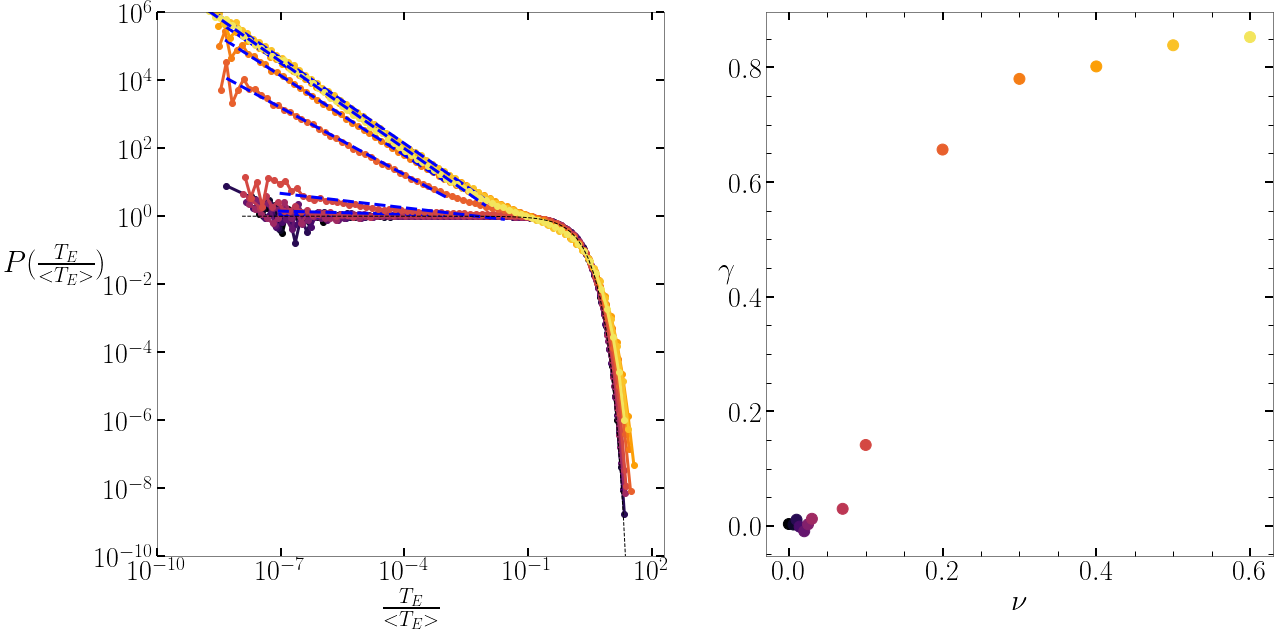

In [4]:
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/DataML/Da1n{nb}' for nb in fnb]

Tnu = [read_parameters(folder)[2] for folder in folderpath]

NCURVES = len(folderpath) + 3 
cmap = plt.cm.get_cmap('viridis')
colors = [cmap(1 - i / NCURVES) for i in range(NCURVES)]

nbins = 100
Tnmin = np.array([15,15,15,15,15,15,10,10,10,  1,1,1,1,1])
Tnmax = np.array([50,50,50,50,50,50,50,50,50, 40,40,50,50,50])
histo, bins, _, Tb2 = test_PDFtpsbava_ML(folderpath, Tnu, nbins, size = 2, nmin = Tnmin, nmax = Tnmax,
                     switch_plot = 1, limdata = 1e8, xlim_min = 1e-10, xlim_max = 2e2, ylim_min = 1e-10, ylim_max = 1e6)

In [4]:
params = read_parameters('/data1/DATA_Duplat/Brut/DataML/Da1n1')
L1 = params[0]
L2 = params[1]
var = 'nu'
fnb = np.arange(1,15)
fpath = [f'/data1/DATA_Duplat/Brut/DataML/Da1n{nb}' for nb in fnb]
Tvar = [read_parameters(folder)[2] for folder in fpath]
Tswitch = np.zeros(len(fpath))
nbins = 100
Tnmin = [4,4,4,4,4,4,4,4,4,4,4,4,4,4]
Tnmax = [50,50,50,50,50,50,50,50,50,50,50,50,50,50]
Tndist, Tndatafit, Tnstat, Tsmax = PDF(fpath, L1, L2, nbins,Tvar, Tswitch, Tnmin, Tnmax, switchplot = 0, col = 3, limdata = 2e8)

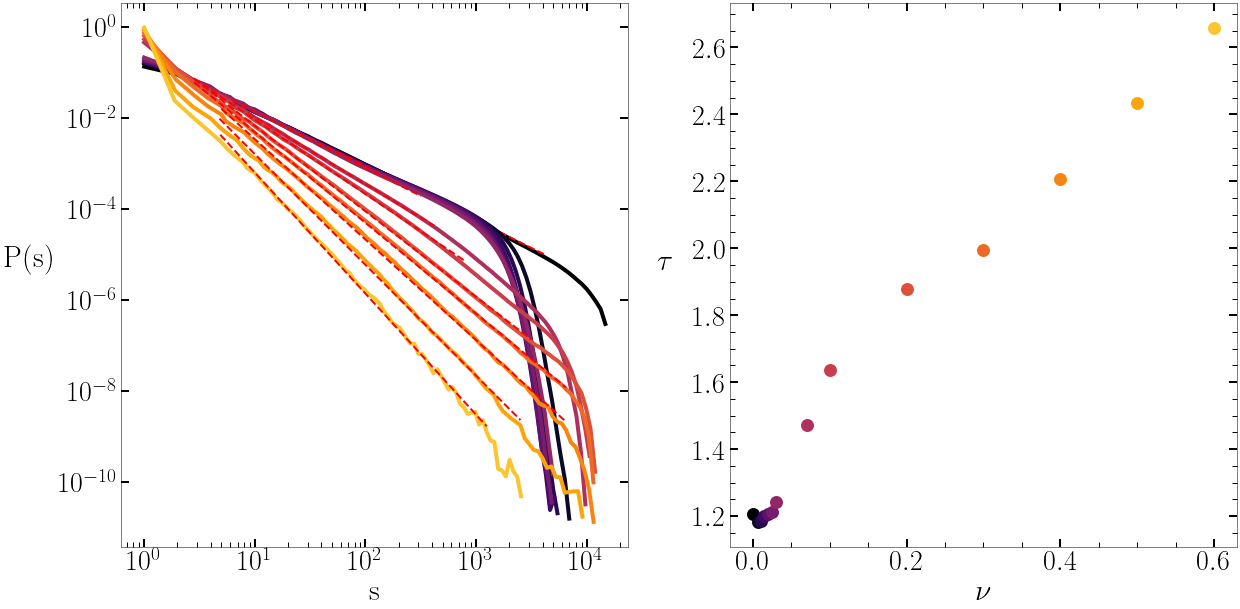

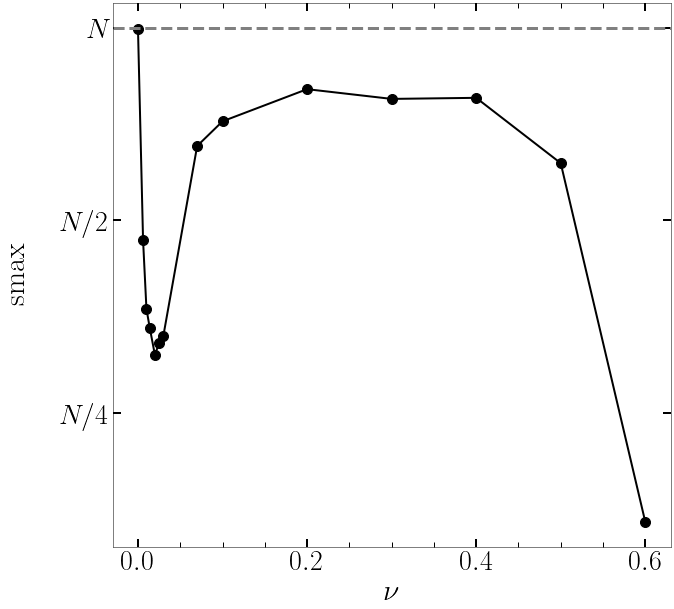

[16279.  7618.  5947.  5550.  5041.  5263.  5399. 10699. 11692. 13127.
 12675. 12724. 10056.  2763.]


In [8]:
stop = [8e-6,7e-4,7e-4,7e-4,3e-4,
        2e-4,2e-4,4e-5, 5e-6,1e-7,
        1e-8, 1e-9, 1e-9, 1e-9]
start_x = [2,2,2,1,1,
           2,2,2,2,2,
           2,4,4,4]
Ttau_Open = np.zeros(len(fpath))
Tperr_Open = np.zeros(len(fpath))


NCURVES = len(fpath) +1
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

# for i in range (len(fpath)):
for i in range (14):
    
    xs_final = 0
    result_final = 0
    perr_final = 1e10
    x_final = 0
    
    mask = Tndist[i, :,1] != 1
    
    ax1.plot(Tndist[i, :,0][mask],Tndist[i, :,1][mask], color = colors[i],
            linewidth=4, markersize=6, mfc="none") 
    
    result, xs, _ , perr = fit_powerlaw(Tndist[i,:,0][mask], Tndist[i,:,1][mask], n_cutoff = stop[i], start_x = start_x[i], plot=True, f_scale=1.0,
                                            function_to_fit='power')
    Ttau_Open[i] = np.round(result.x[1], 3)
    Tperr_Open[i] =  np.round(perr[1], 2)
    ax1.plot(xs, powerlaw(xs, *result.x), 'r--', lw = 2)
    # ax2.errorbar(Tvar[i], - np.round(result.x[1], 2), yerr = np.round(perr[1], 2), fmt = 'o', color = colors[i], lw =2, markersize = 10)
    ax2.scatter(Tvar[i], - np.round(result.x[1], 3), color = colors[i], lw =2, s = 120)
    
    
ax2.plot(Tvar[:1], -Ttau_Open[:1], linestyle = '-', c = 'k', zorder=1)  

ax1.set_xscale("log")
ax1.set_yscale("log")
# ax1.axvline((L1 * L2)/10, lw = 3)
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

# ax2.axvline(0.01, c = "k", lw = 2)
ax2.set_xlabel(r'$\nu$', fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

from matplotlib.ticker import FixedLocator, NullLocator
fig, ax = plt.subplots(figsize = (10,10))

N = L1*L2
yticks = [N, N/2, N/4]

ax.plot(Tvar, Tsmax, marker = 'o', markersize = 10, lw = 2, color = 'k')
ax.axhline(N, c = "grey", lw = 3, ls = '--')
para_fig(ax, r'$\nu$', r'smax', type = 'semilog')
ax.yaxis.set_major_locator(FixedLocator(yticks))  # Supprime tous les autres ticks majeurs
ax.yaxis.set_minor_locator(NullLocator())  # Supprime les ticks mineurs
ax.set_yticklabels([r'$N$', r'$N / 2$', r'$N / 4$'])
plt.show()

print(Tsmax)

## On regarde l'histoire des valeurs négatives

In [ ]:
# data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/DataML/Da1n14/Avalanche_outputB.gz", 10000000)
# data = np.loadtxt("/data1/DATA_Duplat/Brut/DataML/Subbatch/Da1n8/Avalanche_outputB.txt")
print(len(data))
print(min(data[:, 1]))

del(data)


10000000
0.0


#   Subbatch


In [2]:
def process_file_copy(input_path, output_path, max_lines):
    with gzip.open(input_path, 'rt') as fin, open(output_path, 'w') as fout:
        for i, line in enumerate(fin):
            if i >= max_lines:
                break
            fout.write(line)

def file_copy_rearranged(input_path, output_path, max_lines):
    data = read_gz_with_pandas_nrows(input_path, max_lines)
    r_data = data[:, [0,3,2,1,4]]
    with open(output_path, 'w') as fout:
        for i, line in enumerate(r_data):
            if i >= max_lines:
                break
            str = "{}  {}  {}  {}  {}\n".format(line[0], line[1], line[2], line[3], line[4])
            fout.write(str)
    
    del(data)

In [6]:
Tinput_path = ['/data1/DATA_Duplat/Brut/DataML/Da1n{}/Avalanche_outputB.gz'.format(nb) for nb in [5]]
Toutput_path = ['/data1/DATA_Duplat/Brut/DataML/Subbatch2/Da1n{}/Avalanche_outputB.txt'.format(nb) for nb in [5]]
max_lines = 6e6

Parallel(n_jobs=-1)(delayed(process_file_copy)(input_path, output_path, max_lines) for (input_path, output_path) in zip(Tinput_path, Toutput_path))

[0]

In [8]:
input_path = '/data1/DATA_Duplat/Brut/DataML/Da2n1/Avalanche_outputB.gz'
output_path = '/data1/DATA_Duplat/Brut/Test/Te57n1/Avalanche_outputB.txt'
max_lines = 1e4
file_copy_rearranged(input_path, output_path, max_lines)



BadGzipFile: Not a gzipped file (b'40')

In [52]:
data = np.loadtxt('/data1/DATA_Duplat/Brut/DataML/Subbatch/Da1n5/Avalanche_outputB.txt', max_rows = 10)
print(data)

[[3.46075e+05 2.29000e-05 1.61370e+04 4.00000e+00 4.00000e+00 9.86677e+03
  2.30000e-05 7.27300e-02 4.39400e+00]
 [3.46075e+05 1.54000e-04 1.12640e+04 2.00000e+00 2.00000e+00 9.86866e+03
  1.54000e-04 7.27500e-02 2.23000e+00]
 [3.46075e+05 1.21900e-03 1.17400e+03 1.30000e+01 1.30000e+01 9.88834e+03
  1.21900e-03 7.27700e-02 1.54800e+01]
 [3.46075e+05 2.14000e-04 1.50390e+04 2.00000e+00 2.00000e+00 9.89154e+03
  2.14000e-04 7.27400e-02 2.24400e+00]
 [3.46075e+05 6.00000e-06 1.53600e+04 8.00000e+00 8.00000e+00 9.89159e+03
  6.00000e-06 7.27500e-02 9.86500e+00]
 [3.46075e+05 2.55000e-04 3.18900e+03 2.00000e+00 2.00000e+00 9.89474e+03
  2.55000e-04 7.27900e-02 2.13800e+00]
 [3.46075e+05 2.59000e-04 6.45000e+02 1.20000e+01 1.20000e+01 9.89894e+03
  2.59000e-04 7.28000e-02 1.34000e+01]
 [3.46075e+05 5.12000e-04 1.60960e+04 1.27000e+02 1.32000e+02 9.90706e+03
  5.12000e-04 7.27700e-02 1.59900e+02]
 [3.46075e+05 3.25000e-04 9.88000e+02 1.00000e+01 1.00000e+01 9.90857e+03
  3.25000e-04 7.28200e

##  Verif data

In [62]:
#3 set : 70, 10, 20 (train/val/test)
# data = np.loadtxt('/data1/DATA_Duplat/Brut/DataML/Subbatch/Da2n1/Avalanche_outputB.txt')
data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/DataML/Da2n1/Avalanche_outputB.gz", 10000000)
print(data[:10])

[[4.09134e+04 1.89000e+02 1.29290e+04 1.67000e-04 1.93000e+02 4.60000e+01]
 [4.09134e+04 1.00000e+00 8.31900e+03 7.83700e-04 1.00000e+00 1.00000e+00]
 [4.09134e+04 1.00000e+00 4.73600e+03 4.27400e-04 1.00000e+00 1.00000e+00]
 [4.09134e+04 1.00000e+01 8.44600e+03 3.73600e-04 1.00000e+01 5.00000e+00]
 [4.09134e+04 3.00000e+00 1.63390e+04 9.62800e-05 3.00000e+00 3.00000e+00]
 [4.09134e+04 1.00000e+00 1.13720e+04 6.68000e-05 1.00000e+00 1.00000e+00]
 [4.09134e+04 1.00000e+00 1.12410e+04 1.07300e-04 1.00000e+00 1.00000e+00]
 [4.09134e+04 8.90000e+01 1.57220e+04 3.43100e-04 9.70000e+01 3.40000e+01]
 [4.09134e+04 1.00000e+00 6.29800e+03 2.21800e-04 1.00000e+00 1.00000e+00]
 [4.09134e+04 1.00000e+00 6.42400e+03 4.11200e-04 1.00000e+00 1.00000e+00]]


In [63]:
# print(data[:10])
# print(np.shape(data))
npoint = len(data)
data_train = data[:int(npoint*0.7)]
data_test = data[int(npoint*0.7):int(npoint*0.8)]
data_val = data[int(npoint*0.8):]

Train set:
Mean intertime: 0.00020380109464991536
Max intertime: 0.004133
Min intertime: 0.0
Test set:
Mean intertime: 0.00020886962510504375
Max intertime: 0.005033
Min intertime: 0.0
Validation set:
Mean intertime: 0.00020782066947423234
Max intertime: 0.004894
Min intertime: 0.0
2.22e-16


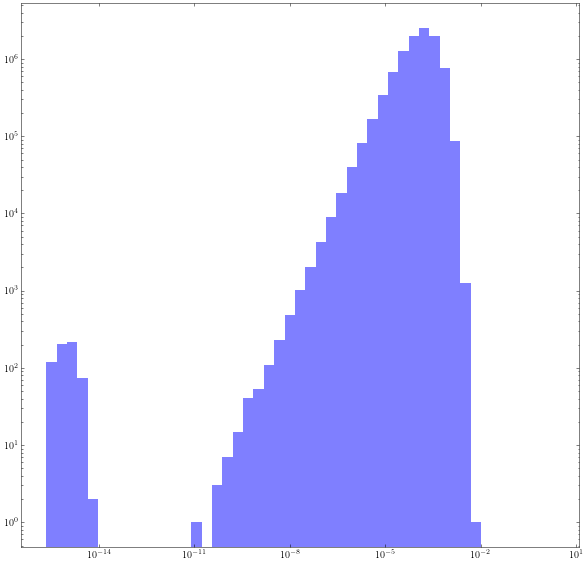

[3.553e-15 4.441e-16 4.441e-16 4.441e-16 4.441e-16 8.882e-16 1.776e-15
 1.776e-15 4.441e-16 4.441e-16 4.441e-16 4.441e-16 8.882e-16 8.882e-16
 8.882e-16 1.776e-15 1.776e-15 3.553e-15 3.553e-15 8.882e-16 8.882e-16
 8.882e-16 2.220e-16 4.441e-16 8.882e-16 8.882e-16 1.776e-15 1.776e-15
 1.776e-15 4.441e-16 4.441e-16 4.441e-16 8.882e-16 8.882e-16 1.776e-15
 1.776e-15 3.553e-15 2.220e-16 4.441e-16 1.776e-15 3.553e-15 8.882e-16
 1.776e-15 3.553e-15 7.105e-15 7.105e-15 3.553e-15 2.220e-16 4.441e-16
 4.441e-16 1.776e-15 1.776e-15 3.553e-15 1.776e-15 1.776e-15 2.220e-16
 8.882e-16 8.882e-16 1.776e-15 1.776e-15 4.441e-16 4.441e-16 8.882e-16
 8.882e-16 1.776e-15 1.776e-15 1.776e-15 1.776e-15 1.776e-15 1.776e-15
 1.776e-15 1.776e-15 1.776e-15 1.776e-15 1.776e-15 8.882e-16 8.882e-16
 8.882e-16 8.882e-16 1.776e-15 1.776e-15 1.776e-15 1.776e-15 1.776e-15
 1.776e-15 1.776e-15 2.220e-16 2.220e-16 2.220e-16 2.220e-16 4.441e-16
 4.441e-16 1.776e-15 1.776e-15 2.220e-16 2.220e-16 2.220e-16 4.441e-16
 8.882

In [72]:
print("Train set:")
print("Mean intertime:", np.mean(data_train[:,3]))
print("Max intertime:", np.max(data_train[:,3]))
print("Min intertime:", np.min(data_train[:,3]))

print("Test set:")
print("Mean intertime:", np.mean(data_test[:,3]))
print("Max intertime:", np.max(data_test[:,3]))
print("Min intertime:", np.min(data_test[:,3]))

print("Validation set:")
print("Mean intertime:", np.mean(data_val[:,3]))
print("Max intertime:", np.max(data_val[:,3]))
print("Min intertime:", np.min(data_val[:,3]))

mask = data[:,3] > 0
data_f = data[mask]
print(np.min(data_f[:,3]))
fig, ax = plt.subplots(figsize =(10,10))
ax.hist(data_f[:,3], bins = np.logspace(np.log10(np.min(data_f[:,3])), np.log10(2)), color = 'blue', alpha = 0.5, label = 'Train')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

mask2  = (data_f[:,3] < 1e-12)
print(data_f[:,3][mask2])


In [32]:
Tfolderpath = ['/data1/DATA_Duplat/Brut/DataML/Da1n{}'.format(nb) for nb in range(1,15)]
Tnu = [read_parameters(folder)[2] for folder in Tfolderpath]

# print(Tnu)

with open("/data1/DATA_Duplat/Brut/DataML/Subbatch/Analysis.txt", 'w') as f:
    for i in range(1,15):
        data = np.loadtxt('/data1/DATA_Duplat/Brut/DataML/Subbatch/Da1n{}/Avalanche_outputB.txt'.format(i))
        npoint = len(data)
        data_train = data[:int(npoint*0.7)]
        data_test = data[int(npoint*0.7):int(npoint*0.8)]
        data_val = data[int(npoint*0.8):]
        
        f.write("Dissipation : {}".format(Tnu[i-1]))
        f.write("Train set:\n")
        f.write("Mean intertime: {}\n".format(np.mean(data_train[:,1])))
        f.write("Max intertime: {}\n".format(np.max(data_train[:,1])))
        f.write("Min intertime: {}\n".format(np.min(data_train[:,1])))

        f.write("Test set:\n")
        f.write("Mean intertime: {}\n".format(np.mean(data_test[:,1])))
        f.write("Max intertime: {}\n".format(np.max(data_test[:,1])))
        f.write("Min intertime: {}\n".format(np.min(data_test[:,1])))

        f.write("Validation set:\n")
        f.write("Mean intertime: {}\n".format(np.mean(data_val[:,1])))
        f.write("Max intertime: {}\n".format(np.max(data_val[:,1])))
        f.write("Min intertime: {}\n".format(np.min(data_val[:,1])))
        f.write("\n")

#   Tmean between S>N/100

In [ ]:
L1 = 256
L2 = 256

nbline = 0
tini = 0

last_n = 0
sum_diff = 0
norm = 0

csize = 1e6
nmax = 1e8

folder = "/data1/DATA_Duplat/Brut/PDF/PD7n1/Avalanche_outputB.gz"
for chunk in chunked_file_reader(folder, chunksize=csize, usecols=[1]):
    
    size = np.array(chunk.iloc[:,0])
    n = np.arange(1,len(size)+1) + tini
    tini = n[-1]
    
    mask = size >= ((L1 * L2)/100)
    f_n = n[mask]
    
    if nbline > 0:
        f_n = np.insert(f_n, 0, last_n)
    
    if len(f_n) != 0:
        last_n = f_n[-1]
    
        f_diff = np.diff(f_n)
    
        sum_diff += np.sum(f_diff)
        norm += len(f_diff)
        
    print(sum_diff/norm)
    nbline += csize
    if csize >= nmax:
        break

In [3]:
def process_meantime(folder, size_min = 1000, csize = 1e6, nmax = 1e8):
    nbline = 0
    tini = 0
    
    last_n = 0
    sum_diff = 0
    norm = 0
    
    for chunk in chunked_file_reader(folder, chunksize=csize, usecols=[1]):
        
        size = np.array(chunk.iloc[:,0])
        n = np.arange(1,len(size)+1) + tini
        tini = n[-1]
        
        mask = size > size_min
        f_n = n[mask]
        
        if nbline > 0:
            f_n = np.insert(f_n, 0, last_n)
        
        if len(f_n) != 0:
            last_n = f_n[-1]
        
            f_diff = np.diff(f_n)
        
            sum_diff += np.sum(f_diff)
            norm += len(f_diff)
        
        nbline += csize
        if csize >= nmax:
            break
        
    if norm == 0:
        return 0
    
    return(sum_diff/norm)

In [4]:
Tfolderpath = ["/data1/DATA_Duplat/Brut/PDF/PD5n{}".format(n) for n in range(1, 15)]

for i in range(6):
    Tfolderpath[i] = "/data1/DATA_Duplat/Brut/PDF/PD7n{}".format(i+1)

print(Tfolderpath)
params = read_parameters(Tfolderpath[0])
L1 = params[0]
L2 = params[1]

['/data1/DATA_Duplat/Brut/PDF/PD7n1', '/data1/DATA_Duplat/Brut/PDF/PD7n2', '/data1/DATA_Duplat/Brut/PDF/PD7n3', '/data1/DATA_Duplat/Brut/PDF/PD7n4', '/data1/DATA_Duplat/Brut/PDF/PD7n5', '/data1/DATA_Duplat/Brut/PDF/PD7n6', '/data1/DATA_Duplat/Brut/PDF/PD5n7', '/data1/DATA_Duplat/Brut/PDF/PD5n8', '/data1/DATA_Duplat/Brut/PDF/PD5n9', '/data1/DATA_Duplat/Brut/PDF/PD5n10', '/data1/DATA_Duplat/Brut/PDF/PD5n11', '/data1/DATA_Duplat/Brut/PDF/PD5n12', '/data1/DATA_Duplat/Brut/PDF/PD5n13', '/data1/DATA_Duplat/Brut/PDF/PD5n14']


In [6]:
results = Parallel(n_jobs=-1)(delayed(process_meantime)("{}/Avalanche_outputB.gz".format(folder), L1*L2/10, nmax= 1e7) for folder in Tfolderpath)
print(np.shape(results))

(14,)


In [7]:
print(np.round(results))


[2.300000e+01 2.310000e+02 1.113000e+03 1.763000e+03 1.183000e+03
 9.400000e+02 7.260000e+02 6.380000e+02 1.484000e+03 4.343000e+03
 1.405800e+04 1.014840e+05 3.088079e+06 0.000000e+00]


#   Image analysis

In [3]:
data_large = np.loadtxt("/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/prediction_s3.txt", comments='#', dtype= int)
data_small = np.loadtxt("/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/prediction_s1.txt", comments='#', dtype= int)

In [4]:
sort_data_large = np.array(data_large[data_large[:,1].argsort()[::-1]], dtype = int)

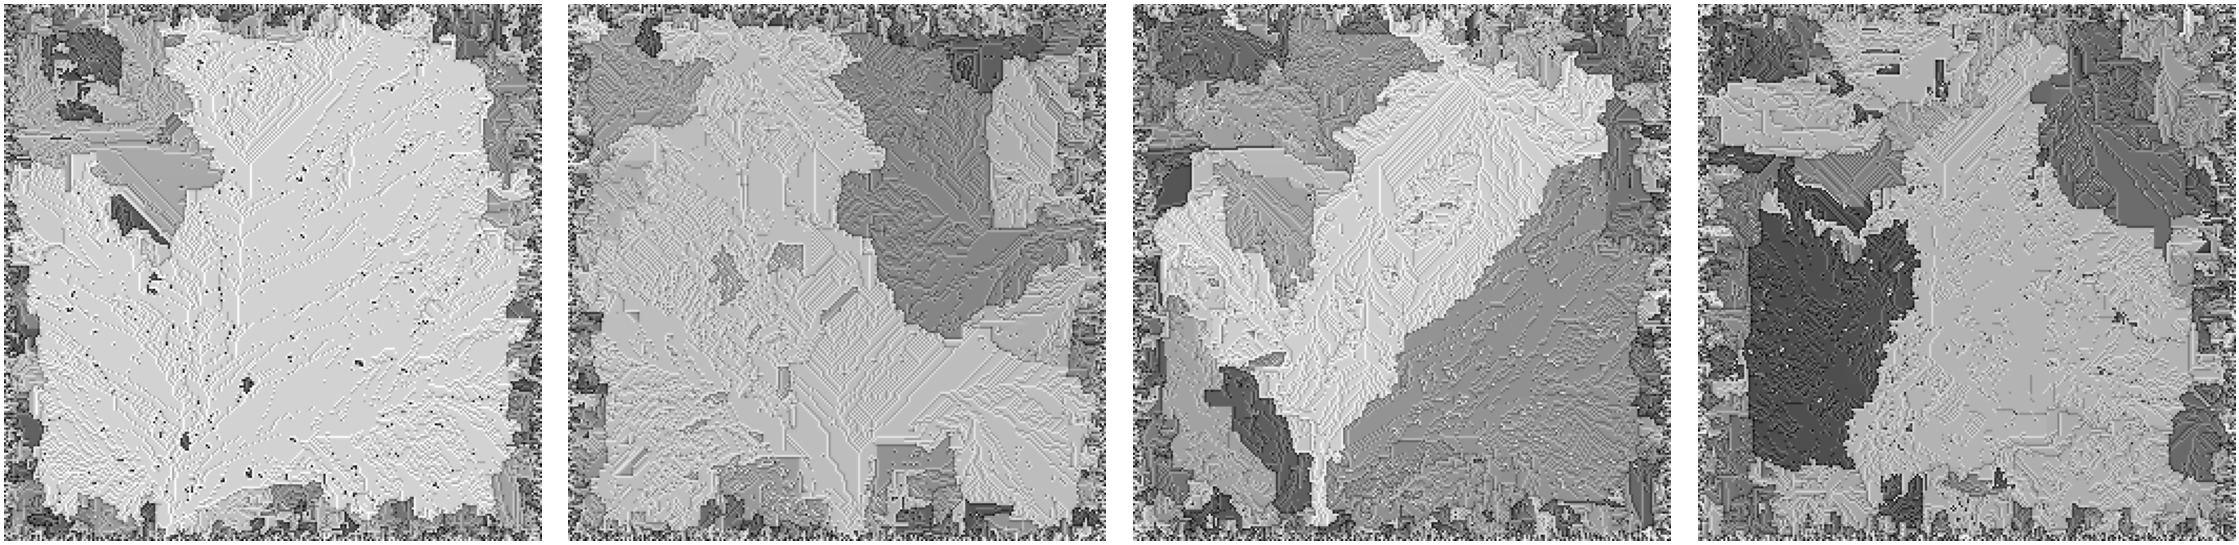

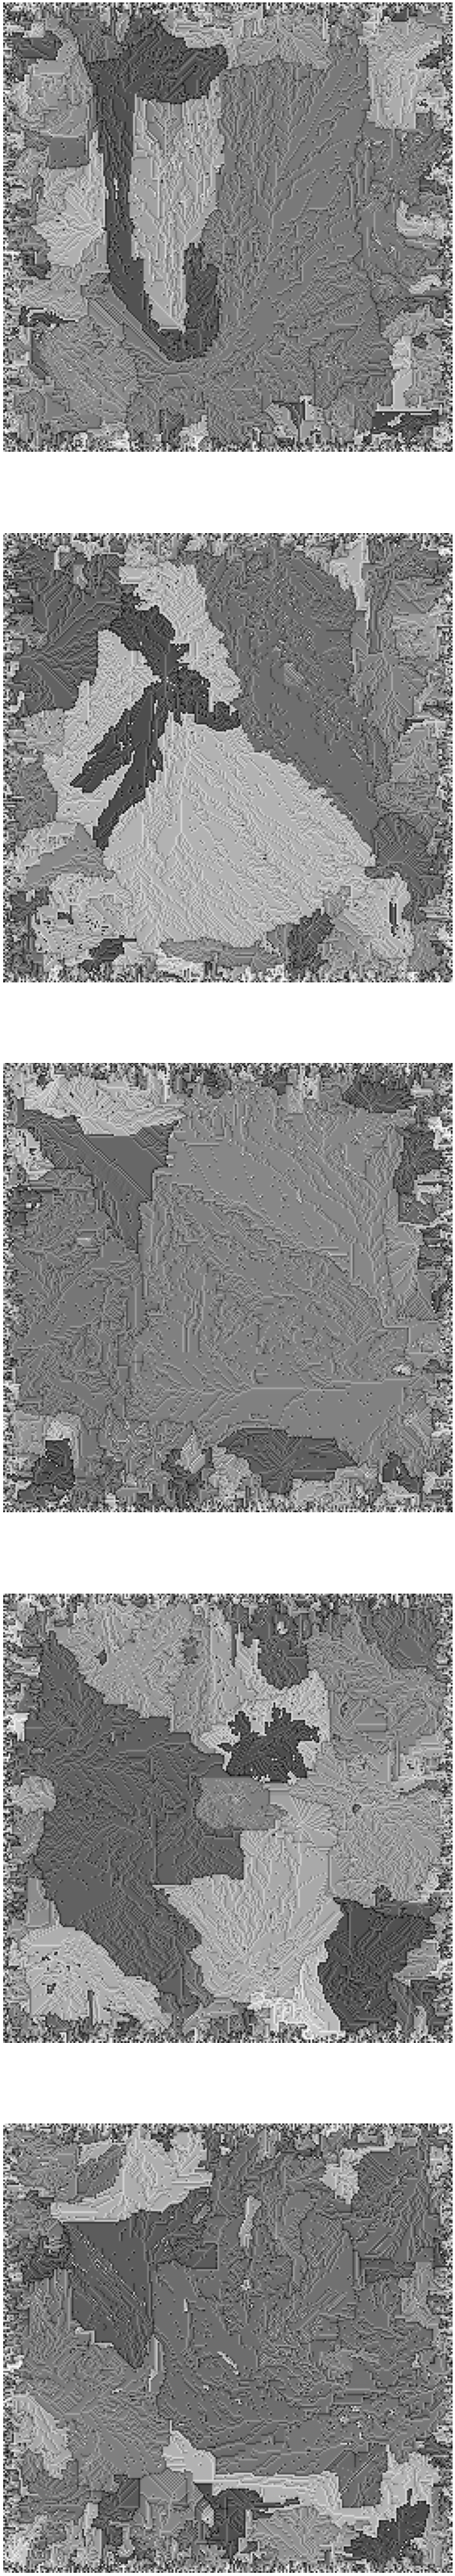

In [8]:
L1 = 256
L2 = 256
snapshotsbis(['/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(sort_data_large[0,0]),
              '/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(sort_data_large[100,0]),
              '/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(sort_data_large[500,0]),
              '/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(sort_data_large[1000,0]),
            ], L1, L2, switch=0, sizeploth =40, sizeplotw = 10)

snapshotsbis(['/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(data_small[0,0]),
              '/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(data_small[100,0]),
              '/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(data_small[500,0]),
              '/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(data_small[1000,0]),
              '/data1/DATA_Duplat/Brut/Memory_effects/Me1n4/Snapshots/nav{}.txt'.format(data_small[1500,0]),
            ], L1, L2, switch=0, sizeploth =10, sizeplotw = 60)

#   Size proportion

In [2]:
file = "/data1/DATA_Duplat/Brut/PDF/PD5n12/stat_histosize.txt"
data = np.loadtxt(file, comments="#", dtype= int)

In [3]:
N = 256*256

smin = [N//100, N//10, N+1]

Nc1 = data[1]
Nc2 = np.sum(data[smin[0]: smin[1]])
Nc3 = np.sum(data[smin[1]: smin[2]])

print(Nc1/Nc2)
print(Nc1/Nc3)

4480.842226331691
73913.18136526228
